# Import thư viện

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

## Đọc dữ liệu từ file csv

In [2]:
df_th = pd.read_csv('C:\\CS114\\th-public.csv')
df_total = pd.read_csv('C:\\CS114\\annonimized.csv')

## Tổng quan về dữ liệu

In [3]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  object
 10  judgement                        295198 non-null  object
dtypes: int64(3), object(8)
memory usage: 24.8+ MB


In [4]:
df_th.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   hash    761 non-null    object
 1   TH      755 non-null    object
dtypes: object(2)
memory usage: 12.0+ KB


### Chuyển cột điểm về dạng số

In [5]:
df_th['TH'] = pd.to_numeric(df_th['TH'], errors='coerce')

### Ghép file annonimized và file điểm

In [6]:
df = pd.merge(df_total, df_th, left_on="concat('it001', username)", right_on='hash', how='outer')

### Xóa các đặc trưng không dùng đến việc dự đoán điểm THỰC HÀNH

In [7]:
delete_columns = ['created_at', 'updated_at', 'hash', 'status', 'judgement']
df = df.drop(columns=delete_columns)

In [8]:
print(df.columns.tolist())


["concat('it001',`assignment_id`)", "concat('it001',`problem_id`)", "concat('it001', username)", 'is_final', 'pre_score', 'coefficient', "concat('it001',`language_id`)", 'TH']


In [9]:
df = df.groupby("concat('it001', username)").agg({
    "concat('it001',`assignment_id`)": pd.Series.nunique,
    "concat('it001',`problem_id`)": pd.Series.nunique,
    'pre_score': 'mean',
    'coefficient': 'mean',
    "concat('it001',`language_id`)": pd.Series.nunique,
    'is_final': 'sum',
    'TH': 'first'
})

df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

df = df.rename(columns={
    "concat('it001',`assignment_id`)": 'n_assignments',
    "concat('it001',`problem_id`)": 'n_problems',
    'pre_score_mean': 'pre_score',
    'coefficient_mean': 'coefficient',
    "concat('it001',`language_id`)": 'n_languages',
    'is_final_sum': 'is_final',
    'TH_first': 'TH'
})

df = df.reset_index()

In [10]:
df.head()

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,TH
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,100.000000,1,46,5.0
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,100.000000,1,78,8.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,100.000000,1,67,7.0
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,4,47,5952.760000,100.000000,1,47,NaN
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,97.196262,1,66,10.0


### Chia tập train / test

In [11]:
df_final = df[df['TH'].notna()]

X = df_final.drop(columns=["concat('it001', username)", 'TH'])
y = df_final['TH']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

test_df = df[df['TH'].isna()]
X_test = test_df.drop(columns=["concat('it001', username)", 'TH'])

In [12]:
df_final

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,TH
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,100.000000,1,46,5.0
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,100.000000,1,78,8.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,100.000000,1,67,7.0
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,97.196262,1,66,10.0
5,014c59c6433fd764a0b08de6ffeb757eaf60aa73,9,90,5240.025126,100.000000,1,90,6.0
...,...,...,...,...,...,...,...,...
796,840d07858c03f80f4695056e2cc7d0c474b83a25,6,43,5171.639640,100.000000,1,44,6.0
797,844f5db2e7e31ae51eba025480679ed7e4708ac6,17,104,4785.224090,100.000000,1,104,8.5
798,845acd04a77b3d1b623f255d9f9f8eae90892dab,8,52,4247.296774,100.000000,1,53,5.5
799,8460eaaf887a6289fb156f7562fb739ba8e9629e,12,114,4278.605027,100.000000,1,115,10.0


### Huấn luyện

In [13]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Dự đoán và đánh giá trên tập kiểm định

In [14]:
y_pred_val = model.predict(X_val)
print("R^2 score trên tập kiểm định:", r2_score(y_val, y_pred_val))

R^2 score trên tập kiểm định: 0.3092001839513061


### Dự đoán kết quả trên tập test

In [15]:
test_df['TH'] = model.predict(X_test)

C:\Users\MrBeast\AppData\Local\Temp\ipykernel_4892\1131466301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['TH'] = model.predict(X_test)


### Lưu kết quả điểm vào file csv để nộp

In [16]:
combined_df = pd.concat([
    df_final[["concat('it001', username)", 'TH']],
    test_df[["concat('it001', username)", 'TH']]
])

combined_df.to_csv('result.csv', index=False, header=False, encoding='utf-8')

### Lưu lại mô hình

In [17]:
joblib.dump(model, 'best_model.pkl')

['best_model.pkl']

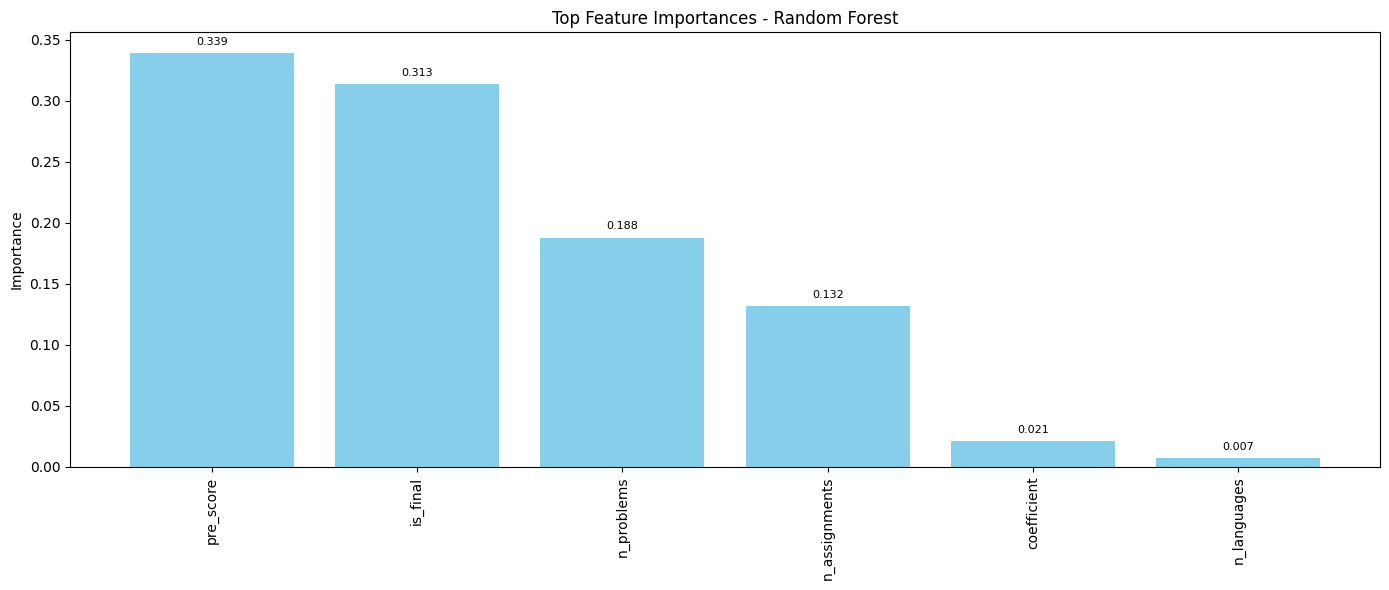

In [18]:
importances = model.feature_importances_
feature_names = X_train.columns 

indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

top_k = min(20, len(importances))
sorted_importances = sorted_importances[:top_k]
sorted_features = sorted_features[:top_k]

# Vẽ
plt.figure(figsize=(14, 6))
bars = plt.bar(range(top_k), sorted_importances, color='skyblue', align='center')
plt.xticks(range(top_k), sorted_features, rotation=90)
plt.title('Top Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()

# Ghi nhãn số
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.005, f'{height:.3f}', 
             ha='center', va='bottom', fontsize=8)

plt.show()


In [19]:
df = pd.concat([df_final,test_df])

In [20]:
df

,"concat('it001', username)",n_assignments,n_problems,pre_score,coefficient,n_languages,is_final,TH
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,100.000000,1,46,5.000
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,100.000000,1,78,8.500
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,100.000000,1,67,7.000
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,97.196262,1,66,10.000
5,014c59c6433fd764a0b08de6ffeb757eaf60aa73,9,90,5240.025126,100.000000,1,90,6.000
...,...,...,...,...,...,...,...,...
1484,feb8a2859a011c59efd22ed419cb69288fe03627,9,34,5581.081081,100.000000,1,34,7.715
1485,fef4a3263ed9a8ab14d457694bb8fd86ccd98312,6,77,6204.557692,100.000000,1,78,7.605
1486,ff12d6e2ab80696ed8e22fbe5497e96c68d29076,6,100,4998.466819,100.000000,1,103,7.405
1487,ff3fa2ec64294f37ae968159f810ebeda7966c51,7,34,4343.329787,100.000000,1,34,5.980


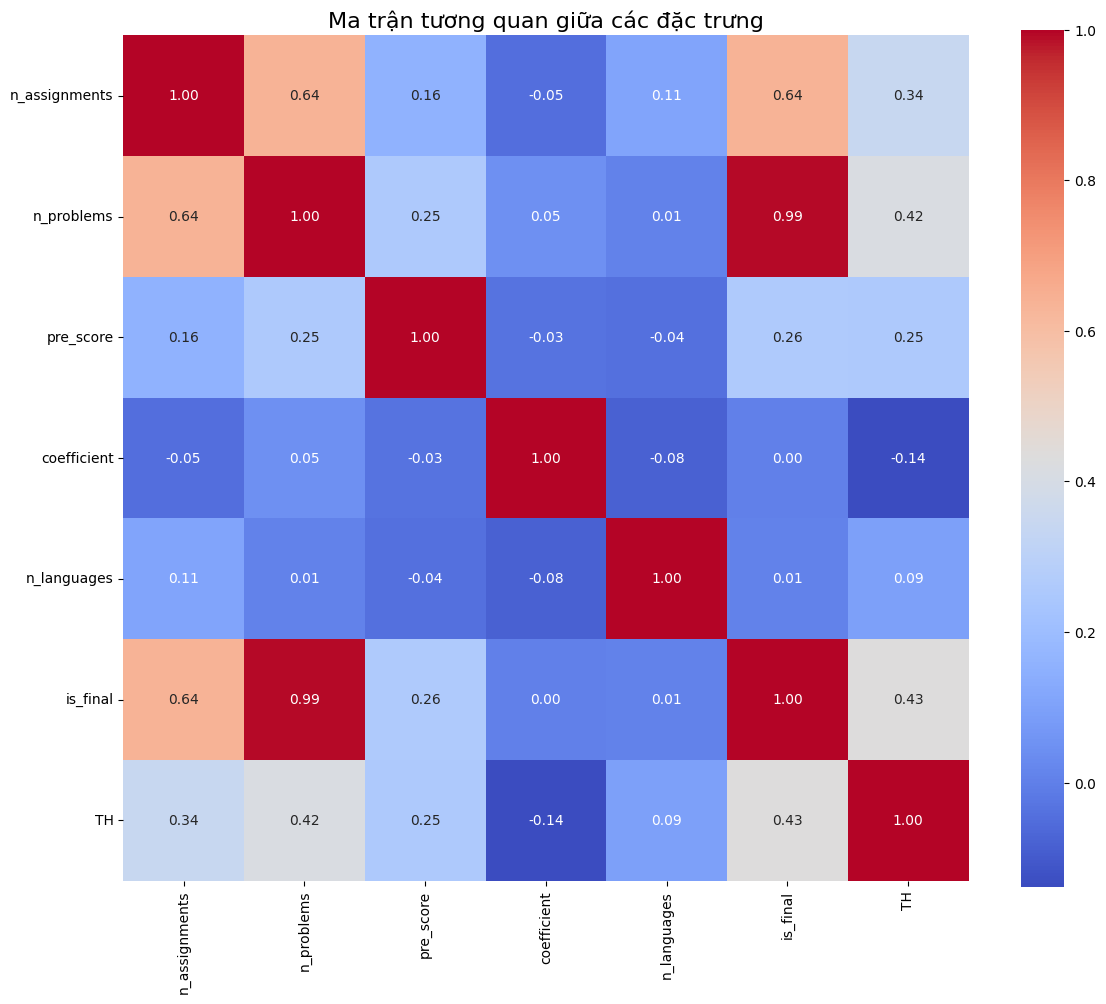

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tính ma trận tương quan
corr_matrix = df.corr(numeric_only=True)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Ma trận tương quan giữa các đặc trưng", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
